# Kakuro: Visión Computacional + Constraint Programming (End-to-End)
**CC58 – Tópicos en Ciencia de la Computación · Trabajo 1**

Integrantes: Diego, Jeffrey

Este notebook implementa el sistema completo que **lee la imagen de un Kakuro, extrae su estructura y lo resuelve con un modelo de Constraint Programming**, proyectando la solución sobre la foto original.

| Fase | Qué hace | Módulo |
|---|---|---|
| 1. Visión + IA | preprocesamiento, localización del tablero, homografía, tamaño de grilla, clasificación de celdas, OCR de pistas con una red neuronal propia (MLP) vs. Tesseract | `kakuro/vision.py`, `kakuro/ocr.py` |
| 2. CP | modelo parametrizado con `AllDifferent`, `Sum`, `Table` (globales) y variante reificada; OR-Tools CP-SAT + motor CP propio | `kakuro/solver.py`, `kakuro/cp_engine.py` |
| 3. Integración | imagen → JSON → solver → superposición de la solución, sin intervención manual | `kakuro/pipeline.py`, `kakuro/visualize.py` |

**Correspondencia con la rúbrica:** precisión de detección (§2.4–2.5), distintas condiciones (§2.6), formulación (§3.1), restricciones globales (§3.2), reificadas (§3.3), puente IA→CP automático (§4), visualización (§4), código modular (paquete `kakuro/`), informe LaTeX (`report/`).

## 0. Configuración
En Google Colab, ejecutar la celda siguiente (clona el repositorio e instala dependencias). En local basta `pip install -r requirements.txt` desde la raíz del repositorio.

In [2]:
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !git clone -q https://github.com/USUARIO/kakuro-cv-cp.git
    %cd kakuro-cv-cp
    !pip -q install -r requirements.txt
    !apt-get -qq install -y tesseract-ocr > /dev/null
sys.path.insert(0, os.path.abspath("."))

In [4]:
import glob, json, time, warnings
import numpy as np, pandas as pd, cv2
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9})

from kakuro.puzzle import Puzzle, combos, allowed_digits, sum_bounds
from kakuro import vision as V
from kakuro.ocr import DigitClassifier
from kakuro.solver import solve, HAS_ORTOOLS, MODELS
from kakuro.evaluate import evaluate_dataset, compare
from kakuro.visualize import overlay_solution, draw_board
from kakuro.pipeline import solve_image

FIG, RES = "report/figures", "results"
os.makedirs(FIG, exist_ok=True); os.makedirs(RES, exist_ok=True)
BACKEND = "ortools" if HAS_ORTOOLS else "native"
print("OR-Tools disponible:", HAS_ORTOOLS, "-> backend principal:", BACKEND)
def save(fig, name):
    fig.savefig(f"{FIG}/{name}.pdf"); fig.savefig(f"{FIG}/{name}.png", dpi=150)

OR-Tools disponible: False -> backend principal: native


## 1. Dataset de prueba
14 imágenes del puzzle en condiciones distintas: versiones **digitales** (limpia, estilo gris, baja resolución + JPEG fuerte, tablero grande) y **fotografías de una hoja impresa** (perspectiva, rotación de 14°, poca luz con ruido, sombra, luz cálida, desenfoque, sobreexposición, escaneo con otro color de bloque, tablero rectangular 8×11).
Cada imagen tiene su *ground truth* en `data/ground_truth/*.json` (estructura, pistas y solución única).
Las imágenes se generan con `scripts/build_dataset.py`; se pueden añadir fotos reales en `data/images/` con su JSON.

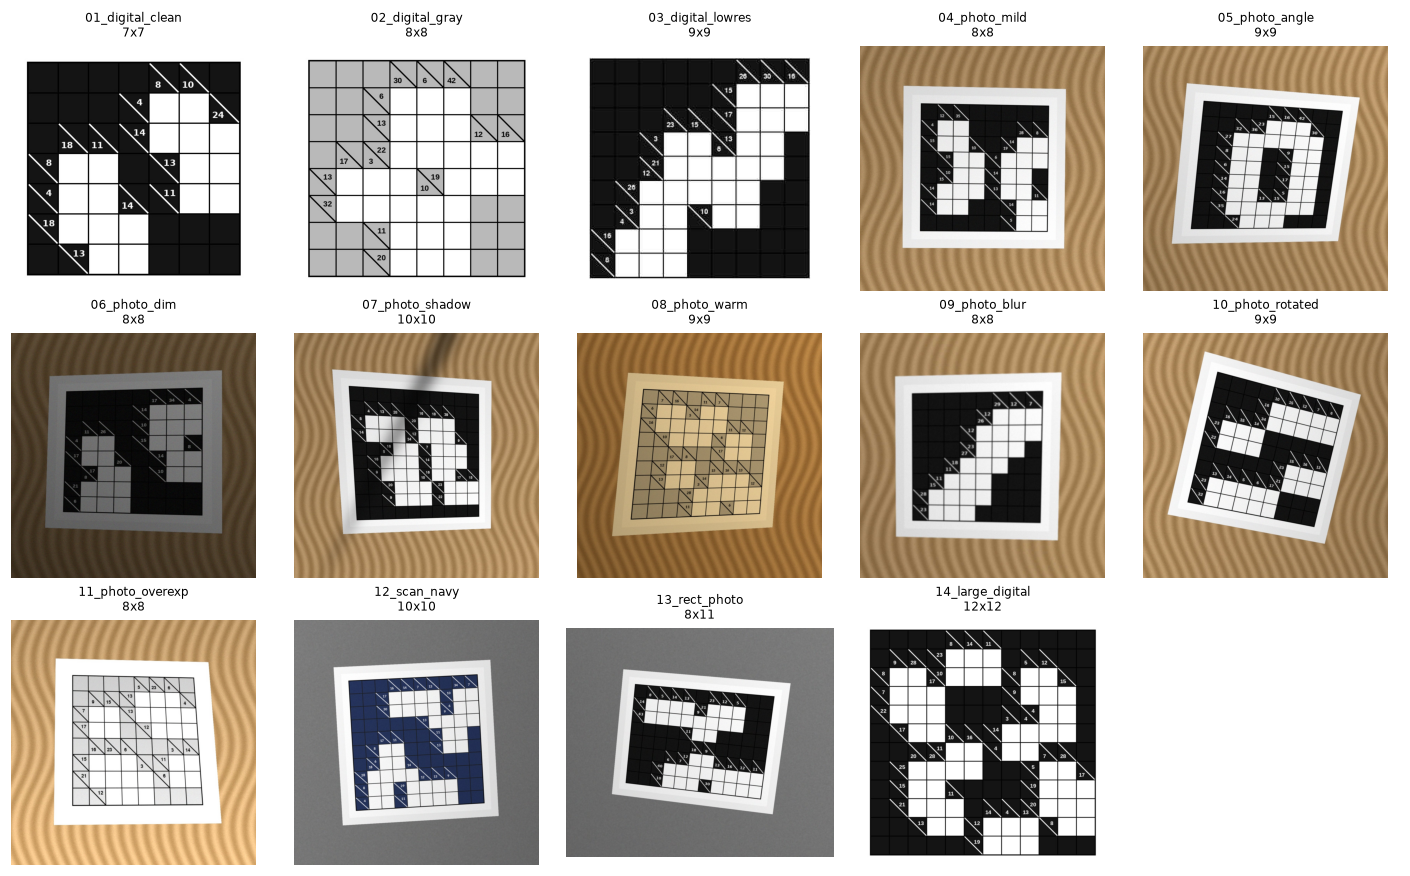

,imagen,tamaño,celdas blancas,pistas,captura,estilo,solución única
0,01_digital_clean,7x7,18,14,digital,classic,True
1,02_digital_gray,8x8,28,16,digital,gray,True
2,03_digital_lowres,9x9,30,18,digital,classic,True
3,04_photo_mild,8x8,26,20,photo,classic,True
4,05_photo_angle,9x9,34,20,photo,classic,True
5,06_photo_dim,8x8,24,18,photo,classic,True
6,07_photo_shadow,10x10,40,26,photo,classic,True
7,08_photo_warm,9x9,32,26,photo,gray,True
8,09_photo_blur,8x8,23,14,photo,classic,True
9,10_photo_rotated,9x9,32,24,photo,classic,True


In [6]:
imgs = sorted(glob.glob("data/images/*.jpg"))
gts = {os.path.basename(p)[:-4]: Puzzle.load(p.replace("images", "ground_truth").replace(".jpg", ".json")) for p in imgs}
fig, axs = plt.subplots(3, 5, figsize=(13, 8))
for ax in axs.ravel(): ax.axis("off")
for ax, p in zip(axs.ravel(), imgs):
    n = os.path.basename(p)[:-4]
    ax.imshow(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)); ax.set_title(f"{n}\n{gts[n].rows}x{gts[n].cols}", fontsize=8)
plt.tight_layout(); save(fig, "dataset"); plt.show()
pd.DataFrame([{"imagen": n, "tamaño": f"{g.rows}x{g.cols}", "celdas blancas": len(g.white_cells()),
               "pistas": len(g.runs()), "captura": g.meta.get("capture"), "estilo": g.meta.get("style"),
               "solución única": g.meta.get("unique")} for n, g in gts.items()])

## 2. Fase 1 — Visión Computacional e IA
### 2.1 Preprocesamiento y localización del tablero
1. Escala de grises y desenfoque gaussiano 5×5.
2. **Umbral adaptativo gaussiano** (ventana ≈ 1/25 del lado de la imagen) combinado con Otsu global.
3. Contornos (`RETR_LIST`) → envolvente convexa → `approxPolyDP` hasta obtener 4 vértices; se exige que el contorno llene ≥ 80 % del cuadrilátero.
4. **Validación con conocimiento del dominio**: en un Kakuro la primera fila y la primera columna son bloques, así que la banda interior superior/izquierda del tablero es oscura (el margen de una hoja de papel no lo es). Entre los candidatos además se exige una grilla periódica clara (ver 2.2).

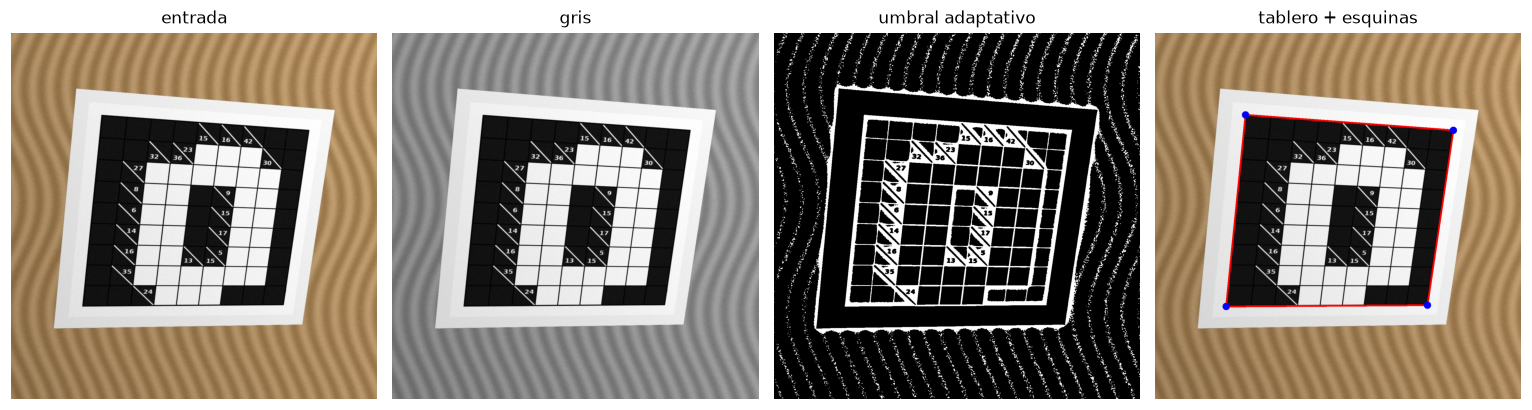

esquinas (TL, TR, BR, BL): [[346.0, 314.0], [1140.0, 373.0], [1041.0, 1041.0], [272.0, 1046.0]]


In [7]:
name = "05_photo_angle"
img = cv2.imread(f"data/images/{name}.jpg")
im, gray, s = V.preprocess(img)
corners, binary = V.find_board(gray)
warped, H = V.warp(im, corners, 900, 900)
vis = im.copy(); cv2.polylines(vis, [corners.astype(int)], True, (0, 0, 255), 6)
for (x, y) in corners.astype(int): cv2.circle(vis, (x, y), 14, (255, 0, 0), -1)
fig, axs = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, (t, a) in zip(axs, [("entrada", cv2.cvtColor(im, cv2.COLOR_BGR2RGB)), ("gris", gray),
                           ("umbral adaptativo", binary), ("tablero + esquinas", cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))]):
    ax.imshow(a, cmap="gray"); ax.set_title(t); ax.axis("off")
plt.tight_layout(); save(fig, "preproc"); plt.show()
print("esquinas (TL, TR, BR, BL):", corners.round(1).tolist())

### 2.2 Corrección de perspectiva y tamaño de la grilla
Se calcula la homografía de las 4 esquinas a un rectángulo (relación de aspecto estimada de los lados). Para estimar el número de celdas $n$ se proyecta la magnitud del gradiente de Sobel por columnas (perfil $P_x$) y por filas ($P_y$). Para cada $n\in[3,30]$:

$$S(n)=\frac{\overline{P(k\,L/n)}_{k=1..n-1}-\overline{P((k+\tfrac12)L/n)}_{k=0..n-1}}{\sigma(P)}$$

Es decir, contraste entre las posiciones esperadas de las líneas y los puntos medios de las celdas. Con $2n$ la mitad de las "líneas" caen en puntos medios ($S$ bajo); con $n/2$ los puntos medios son líneas ($S\approx 0$). Los subarmónicos impares ($n/3$) puntúan alto, por eso se toma el máximo y luego el mayor múltiplo que mantenga ≥ 50 % de su puntaje.

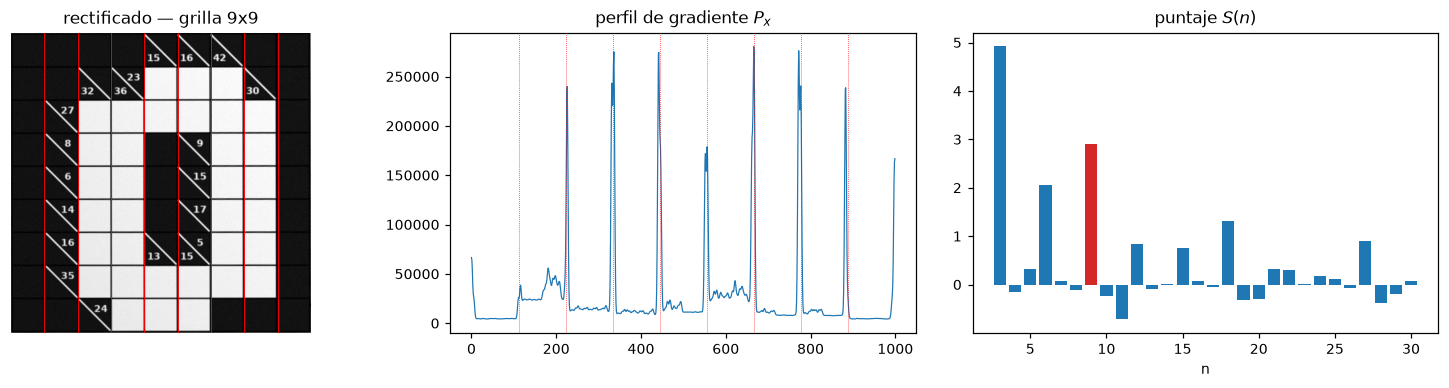

In [8]:
w0, _ = V.warp(gray, corners, 1000, 1000)
rows, cols, dbg = V.estimate_grid(w0)
fig, axs = plt.subplots(1, 3, figsize=(14, 3.6))
axs[0].imshow(w0, cmap="gray"); axs[0].set_title(f"rectificado — grilla {rows}x{cols}"); axs[0].axis("off")
for k in range(1, cols): axs[0].axvline(k * 1000 / cols, color="r", lw=.6)
axs[1].plot(dbg["profile_x"], lw=.8); axs[1].set_title("perfil de gradiente $P_x$")
for k in range(1, cols): axs[1].axvline(k * 1000 / cols, color="r", lw=.5, ls=":")
axs[2].bar(dbg["ns"], dbg["score_x"], color=["tab:red" if n == cols else "tab:blue" for n in dbg["ns"]])
axs[2].set_title("puntaje $S(n)$"); axs[2].set_xlabel("n")
plt.tight_layout(); save(fig, "grid"); plt.show()

### 2.3 Clasificación de celdas (blanca / bloque) con modelo de iluminación
Se rectifica de nuevo a 96 px por celda y se toma la **mediana** del 60 % central de cada celda. Para no confundir un bloque gris bien iluminado con una celda blanca en sombra, se ajusta un **modelo de iluminación cuadrático** $\log L(r,c)=\beta^\top[1,r,c,r^2,c^2,rc]$ con muestras del **papel que rodea el tablero** (anillo a 0.08–0.35 celdas del borde) y, de forma iterativa, con las celdas ya clasificadas como blancas. La razón $\rho=\text{mediana}/L$ se umbraliza con **Otsu** (acotado a [0.55, 0.96]). La primera fila/columna se fuerza a bloque.

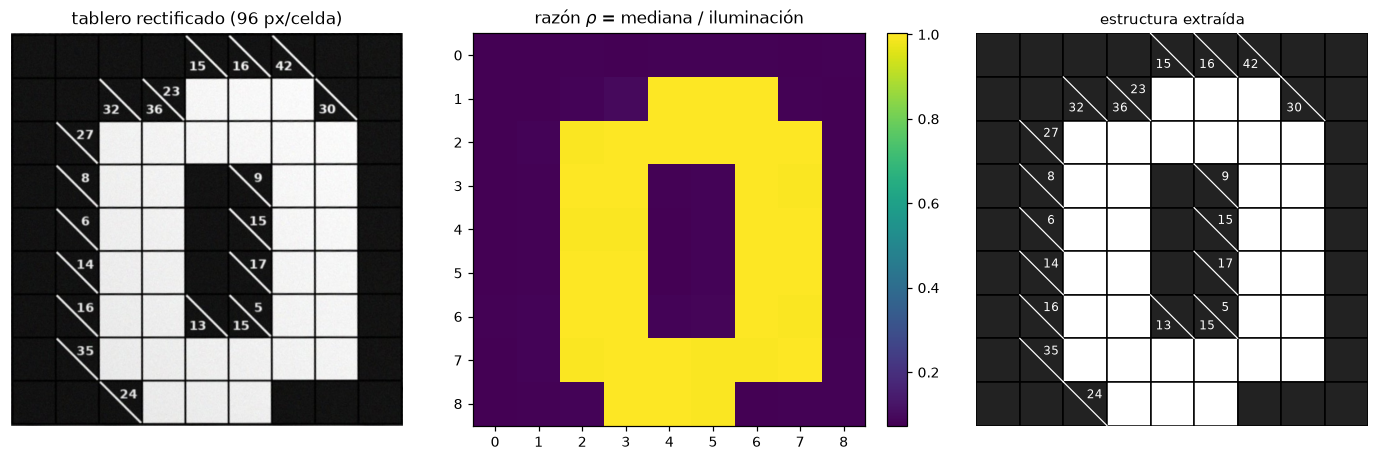

 ### | ### | ### | ### |15\  |16\  |42\  | ### | ### 
 ### | ### |32\  |36\23|  .  |  .  |  .  |30\  | ### 
 ### |  \27|  .  |  .  |  .  |  .  |  .  |  .  | ### 
 ### |  \8 |  .  |  .  | ### |  \9 |  .  |  .  | ### 
 ### |  \6 |  .  |  .  | ### |  \15|  .  |  .  | ### 
 ### |  \14|  .  |  .  | ### |  \17|  .  |  .  | ### 
 ### |  \16|  .  |  .  |13\  |15\5 |  .  |  .  | ### 
 ### |  \35|  .  |  .  |  .  |  .  |  .  |  .  | ### 
 ### | ### |  \24|  .  |  .  |  .  | ### | ### | ### 


In [13]:
clf = DigitClassifier.load("models/digit_mlp.joblib")
vr = V.read_puzzle(img, clf)
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].imshow(cv2.cvtColor(vr.warped, cv2.COLOR_BGR2RGB)); axs[0].set_title("tablero rectificado (96 px/celda)"); axs[0].axis("off")
h = axs[1].imshow(vr.debug["ratio"], cmap="viridis"); plt.colorbar(h, ax=axs[1], fraction=.046)
axs[1].set_title(r"razón $\rho$ = mediana / iluminación")
draw_board(vr.puzzle, ax=axs[2], title="estructura extraída")
plt.tight_layout(); save(fig, "cells"); plt.show()
print(vr.puzzle)

### 2.4 Lectura de pistas: segmentación + red neuronal propia
Para cada bloque que inicia una suma:
* **Polaridad automática** (tinta clara sobre bloque oscuro o tinta oscura sobre bloque gris), contraste respecto a la mediana y **Otsu**.
* **Eliminación de la diagonal**: se estima su desplazamiento real como la moda de $y-x$ de los píxeles de tinta cercanos a $y=x$ (tolera errores de rectificación) y se borra una banda de ±9 % de celda; también se descartan componentes con forma de línea (relleno < 18 %).
* **Componentes conexas** filtradas por tamaño; su centroide decide el triángulo: superior derecho → pista **horizontal**, inferior izquierdo → **vertical**. Dígitos pegados (ancho > 1.15·alto) se separan.
* Cada dígito se normaliza a 28×28 y se clasifica con un **MLP (256-128) sobre HOG + píxeles 14×14**, entrenado con 24 000 dígitos sintéticos en **12 tipografías distintas a las del dataset** (aumentos: rotación ±7°, escala, grosor, baja resolución, desenfoque, ruido).

Exactitud en validación sintética (dígitos aislados): 0.9436


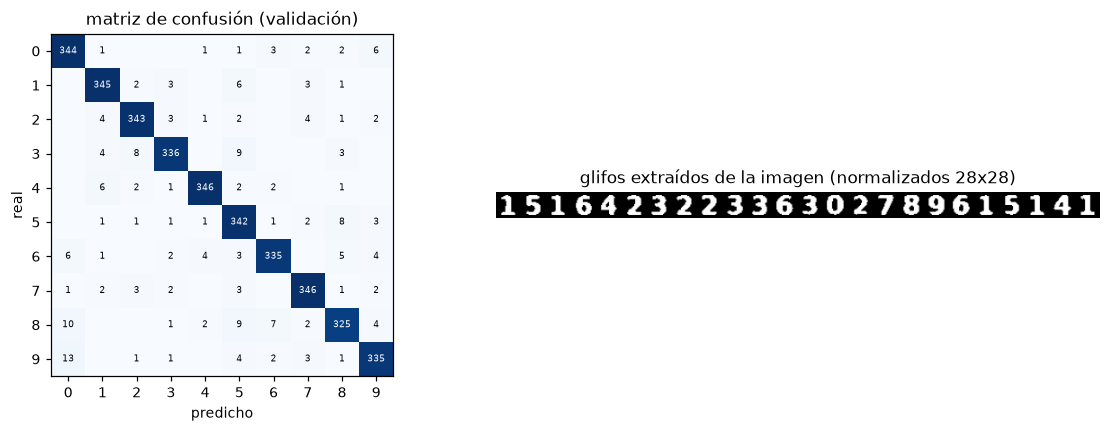

In [14]:
TRAIN = False   # True para re-entrenar (≈ 40 s)
if TRAIN:
    clf = DigitClassifier.train("assets/fonts/train", per_font_digit=200)
    clf.save("models/digit_mlp.joblib")
else:
    # se regenera una partición de validación para reportar métricas
    from kakuro.ocr import synth_digits
    Xv, yv = synth_digits("assets/fonts/train", per_font_digit=30, seed=123)
    clf.val_data = (Xv, yv)
Xv, yv = clf.val_data
pred = clf.model.predict(Xv)
from sklearn.metrics import confusion_matrix, classification_report
acc_val = (pred == yv).mean()
print(f"Exactitud en validación sintética (dígitos aislados): {acc_val:.4f}")
cm = confusion_matrix(yv, pred)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].imshow(cm, cmap="Blues"); axs[0].set_xticks(range(10)); axs[0].set_yticks(range(10))
for i in range(10):
    for j in range(10):
        if cm[i, j]: axs[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=6,
                                 color="white" if cm[i, j] > cm.max() / 2 else "black")
axs[0].set_xlabel("predicho"); axs[0].set_ylabel("real"); axs[0].set_title("matriz de confusión (validación)")
gl = [g for e in vr.debug["glyphs"] for g in e["glyphs"]][:24]
from kakuro.ocr import normalize_glyph
axs[1].imshow(np.hstack([normalize_glyph(g) for g in gl]), cmap="gray"); axs[1].axis("off")
axs[1].set_title("glifos extraídos de la imagen (normalizados 28x28)")
plt.tight_layout(); save(fig, "ocr"); plt.show()

### 2.5 Corrección guiada por restricciones
La salida del clasificador es una distribución por dígito. Se aprovecha el conocimiento del puzzle:
1. **Rango local**: una suma de $L$ celdas sólo admite pistas en $[\sum_{i=1}^{L} i,\ \sum_{i=10-L}^{9} i]$; se elige la lectura de mayor log-probabilidad (entre las 4 mejores clases de cada dígito) que cumpla el rango.
2. **Invariante global**: $\sum$ pistas horizontales $= \sum$ pistas verticales $=$ suma de todas las celdas blancas. Si no se cumple, se cambia la única pista cuya lectura alternativa restablece la igualdad con la menor pérdida de log-probabilidad.

### 2.6 Evaluación sobre el dataset (métricas de error)
Se comparan tres variantes: MLP + corrección, MLP sin corrección y **Tesseract 5** (LSTM, `--psm 7`, lista blanca de dígitos).

In [15]:
variants = {"MLP + corrección": dict(ocr="mlp", correction=True),
            "MLP sin corrección": dict(ocr="mlp", correction=False),
            "Tesseract 5": dict(ocr="tesseract", correction=False)}
evals = {}
for k, kw in variants.items():
    t0 = time.perf_counter()
    evals[k] = pd.DataFrame(evaluate_dataset("data", clf, solve_backend=BACKEND, **kw))
    print(f"{k:20s} listo en {time.perf_counter() - t0:.1f} s")
main = evals["MLP + corrección"]
cols_show = ["image", "grid_ok", "cells_acc", "clues_ok", "clues_total", "corrections", "solved", "unique",
             "correct_solution", "vision_s", "solve_s"]
main[cols_show]

MLP + corrección     listo en 1.1 s
MLP sin corrección   listo en 1.0 s
Tesseract 5          listo en 0.9 s


,image,grid_ok,cells_acc,clues_ok,clues_total,corrections,solved,unique,correct_solution,vision_s,solve_s
0,01_digital_clean,True,1.0,14,14,0,True,True,True,0.047,3.411e-04
1,02_digital_gray,True,1.0,16,16,0,True,True,True,0.048,1.180e-03
2,03_digital_lowres,True,1.0,18,18,0,True,True,True,0.046,2.173e-03
3,04_photo_mild,True,1.0,20,20,0,True,True,True,0.070,5.097e-04
4,05_photo_angle,True,1.0,20,20,0,True,True,True,0.075,6.148e-03
5,06_photo_dim,True,1.0,18,18,0,True,True,True,0.063,5.000e-04
6,07_photo_shadow,True,1.0,26,26,1,True,True,True,0.087,1.180e-03
7,08_photo_warm,True,1.0,26,26,0,True,True,True,0.079,6.423e-04
8,09_photo_blur,True,1.0,14,14,0,True,True,True,0.060,7.619e-04
9,10_photo_rotated,True,1.0,24,24,0,True,True,True,0.081,4.939e-04


In [16]:
def summary(df):
    return {"grilla correcta": df.grid_ok.mean(),
            "exactitud celdas": df.cells_ok.sum() / df.cells_total.sum(),
            "exactitud pistas": df.clues_ok.sum() / df.clues_total.sum(),
            "tableros exactos": df.exact.mean(),
            "resueltos correctamente": df.correct_solution.mean(),
            "t. visión medio (s)": df.vision_s.mean()}
summ = pd.DataFrame({k: summary(v) for k, v in evals.items()}).T
summ.to_csv(f"{RES}/vision_summary.csv")
per_img = main[["image", "cells_acc", "clues_ok", "clues_total", "correct_solution", "vision_s"]].copy()
per_img["tess_clues_ok"] = evals["Tesseract 5"].clues_ok.values
per_img["raw_clues_ok"] = evals["MLP sin corrección"].clues_ok.values
per_img.to_csv(f"{RES}/vision_per_image.csv", index=False)
summ

,grilla correcta,exactitud celdas,exactitud pistas,tableros exactos,resueltos correctamente,t. visión medio (s)
MLP + corrección,1.0,1.0,1.000,1.000,1.000,0.069
MLP sin corrección,1.0,1.0,0.997,0.929,0.929,0.068
Tesseract 5,1.0,1.0,0.000,0.000,0.000,0.058


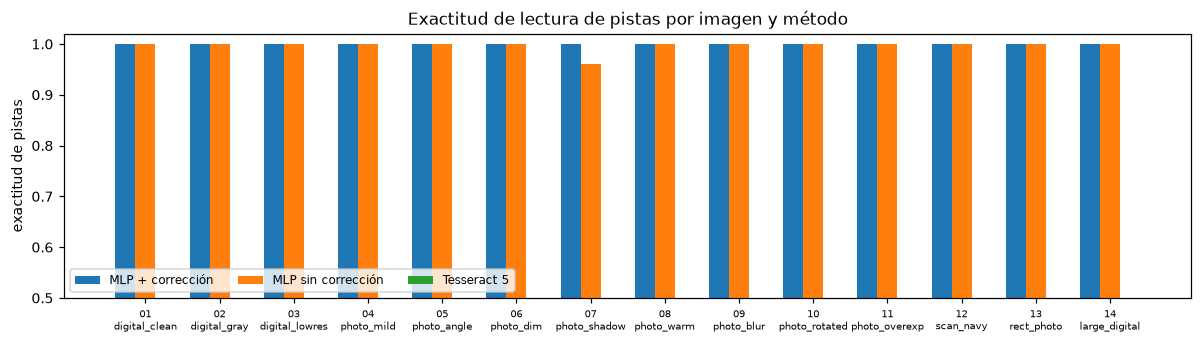

In [17]:
fig, ax = plt.subplots(figsize=(11, 3.2))
x = np.arange(len(main)); w = .27
for i, (k, df) in enumerate(evals.items()):
    ax.bar(x + (i - 1) * w, df.clues_ok / df.clues_total, w, label=k)
ax.set_xticks(x); ax.set_xticklabels([n[:2] + "\n" + n[3:] for n in main.image], fontsize=6.5)
ax.set_ylim(0.5, 1.02); ax.set_ylabel("exactitud de pistas"); ax.legend(fontsize=8, ncol=3, loc="lower left")
ax.set_title("Exactitud de lectura de pistas por imagen y método")
plt.tight_layout(); save(fig, "ocr_compare"); plt.show()

### 2.7 Barrido de robustez
Para cuantificar los límites del sistema, se generan imágenes aleatorias (puzzles, estilos y tipografías al azar) degradando **un factor a la vez** con intensidad creciente (4 imágenes por nivel).

100 imágenes evaluadas en 36 s


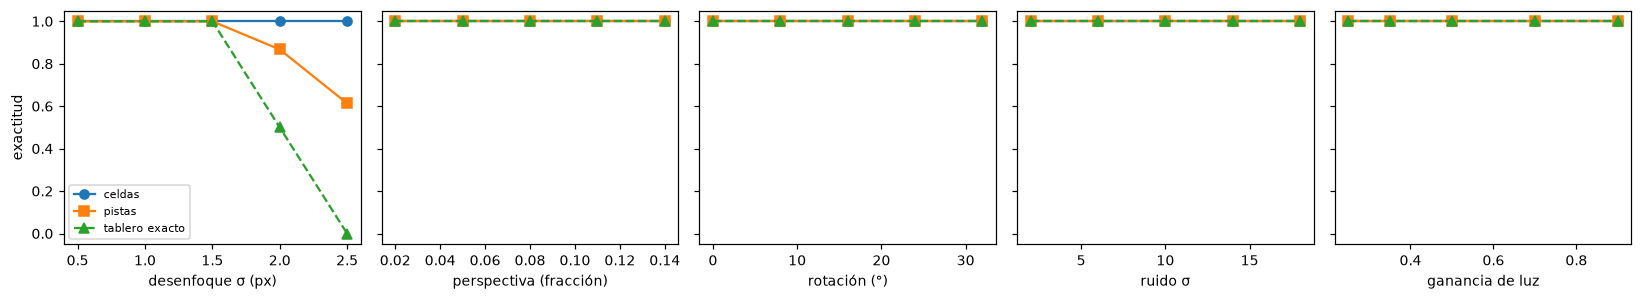

grid_ok  cells_acc  clue_acc  exact
factor      level                                     
blur        0.50       1.0        1.0     1.000    1.0
            1.00       1.0        1.0     1.000    1.0
            1.50       1.0        1.0     1.000    1.0
            2.00       1.0        1.0     0.867    0.5
            2.50       1.0        1.0     0.613    0.0
dark        0.25       1.0        1.0     1.000    1.0
            0.35       1.0        1.0     1.000    1.0
            0.50       1.0        1.0     1.000    1.0
            0.70       1.0        1.0     1.000    1.0
            0.90       1.0        1.0     1.000    1.0
noise       2.00       1.0        1.0     1.000    1.0
            6.00       1.0        1.0     1.000    1.0
            10.00      1.0        1.0     1.000    1.0
            14.00      1.0        1.0     1.000    1.0
            18.00      1.0        1.0     1.000    1.0
perspective 0.02       1.0        1.0     1.000    1.0
            0.05       1.0        1.0     1.000    1.0
            0.08       1.0        1.0     1.000    1.0
            0.11       1.0        1.0     1.000    1.0
            0.14       1.0        1.0     1.000    1.0
rotation    0.00       1.0        1.0     1.000    1.0
            8.00       1.0        1.0     1.000    1.0
            16.00      1.0        1.0     1.000    1.0
            24.00      1.0        1.0     1.000    1.0
            32.00      1.0        1.0     1.000    1.0

In [18]:
from kakuro.robustness import sweep, summarize, LEVELS
t0 = time.perf_counter()
rob = pd.DataFrame([r for f in LEVELS for r in sweep(clf, f, n_per_level=4, seed=1)])
rob.to_csv(f"{RES}/robustness.csv", index=False)
print(f"{len(rob)} imágenes evaluadas en {time.perf_counter() - t0:.0f} s")
names = {"blur": "desenfoque σ (px)", "perspective": "perspectiva (fracción)", "rotation": "rotación (°)",
         "noise": "ruido σ", "dark": "ganancia de luz"}
fig, axs = plt.subplots(1, 5, figsize=(15, 2.8), sharey=True)
for ax, f in zip(axs, LEVELS):
    g = rob[rob.factor == f].groupby("level")[["cells_acc", "clue_acc", "exact"]].mean()
    ax.plot(g.index, g.cells_acc, "o-", label="celdas"); ax.plot(g.index, g.clue_acc, "s-", label="pistas")
    ax.plot(g.index, g.exact, "^--", label="tablero exacto"); ax.set_xlabel(names[f]); ax.set_ylim(-0.05, 1.05)
axs[0].legend(fontsize=7); axs[0].set_ylabel("exactitud")
plt.tight_layout(); save(fig, "robustness"); plt.show()
rob.groupby(["factor", "level"])[["grid_ok", "cells_acc", "clue_acc", "exact"]].mean()

## 3. Fase 2 — Modelo de Constraint Programming
### 3.1 Formulación formal
Sea $\mathcal{W}$ el conjunto de celdas blancas y $\mathcal{R}$ el conjunto de **sumas** (*runs*); cada $R\in\mathcal{R}$ es una secuencia maximal de celdas blancas contiguas (horizontal o vertical) con pista $t_R$.

* **Variables:** $x_c$ para cada $c\in\mathcal{W}$.
* **Dominios:** $D(x_c)=\{1,\dots,9\}$ (modelo base) o el dominio filtrado
  $D(x_c)=\{1..9\}\cap\bigcap_{R\ni c}\ \bigcup\{S\subseteq\{1..9\}: |S|=|R|,\ \textstyle\sum S=t_R\}$.
* **Restricciones** para todo $R\in\mathcal{R}$:
  * $\texttt{AllDifferent}(x_c : c\in R)$ — global.
  * $\sum_{c\in R} x_c = t_R$ — lineal/global `sum`.
  * (modelo `global_dom`) $\texttt{Table}\big((x_c)_{c\in R},\ \{\pi(S)\}\big)$ para $|R|\le 4$: todas las permutaciones de las combinaciones válidas — global de extensión.
* **Objetivo:** ninguno (problema de satisfacción); se verifica además la **unicidad**.

El modelo es **parametrizado**: se construye a partir de cualquier `Puzzle` (salida de la Fase 1) recorriendo sus sumas; nada depende de una instancia concreta.

In [19]:
import inspect
from kakuro import solver as S
print(inspect.getsource(S._build_ortools))

def _build_ortools(puzzle: Puzzle, model_name: str):
    m = cp_model.CpModel()
    cells = puzzle.white_cells()
    runs = puzzle.runs()

    # ---- dominios: {1..9} o filtrados por las combinaciones válidas de sus dos sumas
    dom = {c: set(range(1, 10)) for c in cells}
    if model_name == "global_dom":
        for run in runs:
            ok = set(allowed_digits(len(run), run.total))
            for c in run.cells:
                dom[c] &= ok
    x = {}
    for (r, c) in cells:
        vals = sorted(dom[(r, c)]) or [1]  # dominio vacío -> el modelo será infactible
        x[(r, c)] = m.NewIntVarFromDomain(cp_model.Domain.FromValues(vals), f"x_{r}_{c}")
    if any(not dom[c] for c in cells):
        bad = m.NewBoolVar("empty_domain")      # contradicción explícita
        m.Add(bad == 1)
        m.Add(bad == 0)

    b = {}
    if model_name == "reified":
        # ---- one-hot reificado: b[c,d] <=> (x_c == d)
        for c in cells:
            for d in range(1, 10):
             

Combinaciones de algunas sumas del puzzle extraído:
  down   desde (0, 4): L=2, t=15 -> combos=((6, 9), (7, 8))  dominio=(6, 7, 8, 9)
  down   desde (0, 5): L=2, t=16 -> combos=((7, 9),)  dominio=(7, 9)
  down   desde (0, 6): L=7, t=42 -> combos=((3, 4, 5, 6, 7, 8, 9),)  dominio=(3, 4, 5, 6, 7, 8, 9)
  down   desde (1, 2): L=6, t=32 -> combos=((1, 2, 5, 7, 8, 9), (1, 3, 4, 7, 8, 9), (1, 3, 5, 6, 8, 9), (1, 4, 5, 6, 7, 9), (2, 3, 4, 6, 8, 9), (2, 3, 5, 6, 7, 9), (2, 4, 5, 6, 7, 8))  dominio=(1, 2, 3, 4, 5, 6, 7, 8, 9)
  across desde (1, 3): L=3, t=23 -> combos=((6, 8, 9),)  dominio=(6, 8, 9)
  down   desde (1, 3): L=7, t=36 -> combos=((1, 2, 3, 6, 7, 8, 9), (1, 2, 4, 5, 7, 8, 9), (1, 3, 4, 5, 6, 8, 9), (2, 3, 4, 5, 6, 7, 9))  dominio=(1, 2, 3, 4, 5, 6, 7, 8, 9)

estado=FEASIBLE  única=True  t=0.22 ms  (+0.00 ms prueba de unicidad)  backend=native
solución válida: True | igual al ground truth: True


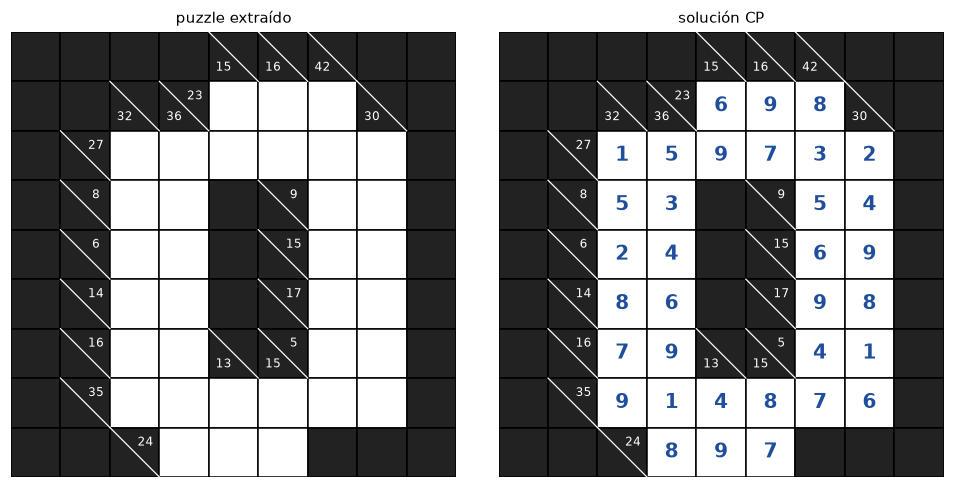

In [21]:
p = vr.puzzle
print("Combinaciones de algunas sumas del puzzle extraído:")
for run in p.runs()[:6]:
    print(f"  {run.direction:6s} desde {run.clue_cell}: L={len(run)}, t={run.total:2d} -> combos={combos(len(run), run.total)}  dominio={allowed_digits(len(run), run.total)}")
res = solve(p, backend=BACKEND, model="global_dom")
print(f"\nestado={res.status}  única={res.unique}  t={1000*res.time_s:.2f} ms  (+{1000*res.time_unique_s:.2f} ms prueba de unicidad)  backend={res.backend}")
print("solución válida:", p.check_solution(res.solution), "| igual al ground truth:", res.solution == gts[name].solution)
fig, axs = plt.subplots(1, 2, figsize=(9, 4.4))
draw_board(p, ax=axs[0], title="puzzle extraído"); draw_board(p, res.solution, ax=axs[1], title="solución CP")
plt.tight_layout(); save(fig, "solution_clean"); plt.show()

### 3.2 Uso de restricciones globales y propagación
`AllDifferent` y `Sum` sobre la **misma** suma interactúan fuertemente: la conjunción equivale a "el conjunto de valores es una de las combinaciones válidas". En CP-SAT esto se aprovecha con la restricción `Table` (para sumas cortas, donde el número de tuplas es pequeño: como mucho 24 por combinación) y con el filtrado de dominios.

El **motor CP propio** (`kakuro/cp_engine.py`) implementa explícitamente el propagador de la conjunción `AllDifferent ∧ Sum` con **consistencia de arco generalizada (GAC)** por programación dinámica sobre subconjuntos: el conjunto de dígitos usados determina la suma, así que basta recorrer las máscaras alcanzables hacia adelante y hacia atrás ($O(L\cdot 2^9\cdot 9)$ por suma). Se compara con una propagación débil (valores fijos + cotas de la suma). El siguiente experimento muestra cuánto poda cada nivel **antes de buscar** (propagación en la raíz):

In [23]:
from kakuro import cp_engine as E
def root_domains(p, level):
    cells = p.white_cells(); idx = {c: i for i, c in enumerate(cells)}
    eng = E.CPSolver(len(cells), [([idx[c] for c in r.cells], r.total) for r in p.runs()], level=level)
    doms = [E.FULL] * len(cells); eng.propagate(doms, list(range(len(eng.cons))))
    return np.array([E.POP[d] for d in doms])
rows_ = []
for n, g in gts.items():
    b, a = root_domains(g, "bounds"), root_domains(g, "gac")
    rows_.append({"imagen": n, "celdas": len(b), "log10 espacio inicial": len(b) * np.log10(9),
                  "log10 tras cotas": np.log10(b).sum(), "log10 tras GAC": np.log10(a).sum(),
                  "fijadas por GAC (%)": 100 * (a == 1).mean()})
prop = pd.DataFrame(rows_); prop.to_csv(f"{RES}/root_propagation.csv", index=False); prop

,imagen,celdas,log10 espacio inicial,log10 tras cotas,log10 tras GAC,fijadas por GAC (%)
0,01_digital_clean,18,17.176,8.595,0.000,100.000
1,02_digital_gray,28,26.719,18.908,0.000,100.000
2,03_digital_lowres,30,28.627,19.678,6.549,40.000
3,04_photo_mild,26,24.810,11.718,0.000,100.000
4,05_photo_angle,34,32.444,23.758,13.621,26.471
5,06_photo_dim,24,22.902,12.473,5.487,50.000
6,07_photo_shadow,40,38.170,26.120,0.000,100.000
7,08_photo_warm,32,30.536,13.905,0.000,100.000
8,09_photo_blur,23,21.948,18.037,0.000,100.000
9,10_photo_rotated,32,30.536,19.908,0.000,100.000


### 3.3 Restricciones reificadas
El modelo principal **no necesita reificación**: todas las reglas del Kakuro son incondicionales (toda suma debe ser exacta y sin repetidos), por lo que se expresan directamente con restricciones globales, que propagan mejor que una descomposición booleana.

La reificación sí se usa donde aporta:
1. **Prueba de unicidad**: tras la primera solución $s$, se añaden literales $d_c$ con $d_c \Rightarrow x_c\neq s_c$ (semi-reificación, `OnlyEnforceIf`) y $\bigvee_c d_c$. Si el modelo pasa a ser infactible, la solución es única.
2. **Modelo alternativo `reified`** (comparación): codificación *one-hot* $b_{c,d}\Leftrightarrow (x_c=d)$, `ExactlyOne` por celda y `AtMostOne`$_d$ por suma en lugar de `AllDifferent`. Sirve para medir el costo de reemplazar la restricción global por su descomposición reificada.

In [24]:
if HAS_ORTOOLS:
    for m in MODELS:
        r = solve(p, backend="ortools", model=m)
        print(f"{m:11s} estado={r.status} única={r.unique} vars={r.stats['num_vars']:4d} restricciones={r.stats['num_constraints']:4d} t={1000*r.time_s:.1f} ms branches={r.stats['branches']}")
else:
    print("OR-Tools no está instalado en este entorno; se usa el motor propio:")
    for m in MODELS:
        r = solve(p, backend="native", model=m)
        print(f"{m:11s} -> nivel {r.stats['level']:6s} estado={r.status} única={r.unique} nodos={r.stats['nodes']} t={1000*r.time_s:.2f} ms")

OR-Tools no está instalado en este entorno; se usa el motor propio:
global      -> nivel bounds estado=FEASIBLE única=True nodos=62 t=8.04 ms
global_dom  -> nivel gac    estado=FEASIBLE única=True nodos=3 t=0.20 ms
reified     -> nivel gac    estado=FEASIBLE única=True nodos=3 t=0.19 ms


### 3.4 Análisis de complejidad y tiempos de respuesta
Decidir si un Kakuro tiene solución es **NP-completo** (Takahiro, 2001; Ruepp & Holzer, 2010), por lo que no se espera un algoritmo polinomial en el peor caso. El espacio de búsqueda ingenuo es $9^{|\mathcal{W}|}$ (≈ $10^{55}$ para 58 celdas). Sin embargo, la propagación de las restricciones globales reduce drásticamente el árbol: en los puzzles con solución única la mayoría de celdas queda fijada en la raíz (ver §3.2) y la búsqueda explora pocos nodos.

Construcción del modelo: $O(|\mathcal{W}| + \sum_R |R|)$ variables/restricciones; tabla: $O(\#\text{combos}\cdot|R|!)$ tuplas, por eso sólo se usa para $|R|\le4$. Se miden tiempos sobre instancias únicas de 6×6 a 18×18 (cacheadas en `data/bench/`).

In [25]:
from kakuro.solver import solve as _solve
bench_files = sorted(glob.glob("data/bench/*.json"))
configs = [("native", "global"), ("native", "global_dom")]
if HAS_ORTOOLS:
    configs += [("ortools", "global"), ("ortools", "global_dom"), ("ortools", "reified")]
brows = []
for f in bench_files:
    pz = Puzzle.load(f); st = pz.stats()
    for be, m in configs:
        reps = [_solve(pz, backend=be, model=m, check_unique=True, time_limit=60) for _ in range(3)]
        r = reps[0]
        brows.append({"size": pz.rows, "white": st["white_cells"], "runs": st["runs"], "backend": be, "model": m,
                      "time_ms": 1000 * np.median([x.time_s for x in reps]),
                      "unique_ms": 1000 * np.median([x.time_unique_s for x in reps]),
                      "nodes": r.stats.get("nodes", r.stats.get("branches")), "status": r.status,
                      "unique": r.unique, "ok": bool(r.solved and pz.check_solution(r.solution))})
bench = pd.DataFrame(brows); bench.to_csv(f"{RES}/bench.csv", index=False)
print("instancias:", len(bench_files), "| todas resueltas y válidas:", bench.ok.all(), "| todas únicas:", bench.unique.all())
bench["cfg"] = bench.backend + "/" + bench.model
bench["total_ms"] = bench.time_ms + bench.unique_ms
tab = bench.groupby(["size", "cfg"]).agg(white=("white", "mean"), total_ms=("total_ms", "mean"), nodes=("nodes", "mean")).unstack("cfg")
tab

instancias: 18 | todas resueltas y válidas: True | todas únicas: True


white                        total_ms                    \
cfg  native/global native/global_dom native/global native/global_dom   
size                                                                   
6           14.000            14.000         0.369             0.026   
8           23.333            23.333         1.382             0.051   
10          38.333            38.333         1.647             0.088   
12          60.667            60.667         7.739             0.253   
14          80.000            80.000        81.258             0.397   
16         102.667           102.667        18.684             0.768   

             nodes                    
cfg  native/global native/global_dom  
size                                  
6            5.000               1.0  
8           12.333               1.0  
10          15.000               1.0  
12          58.000               4.0  
14         639.000               5.0  
16         143.667              16.0

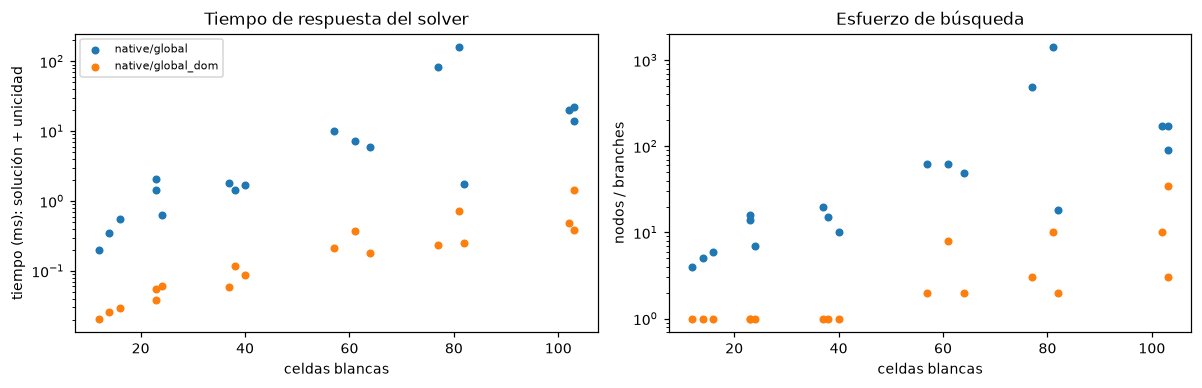

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for cfg, g in bench.groupby("cfg"):
    axs[0].scatter(g.white, g.total_ms, s=18, label=cfg)
    axs[1].scatter(g.white, np.maximum(g.nodes, 1), s=18, label=cfg)
axs[0].set_yscale("log"); axs[0].set_xlabel("celdas blancas"); axs[0].set_ylabel("tiempo (ms): solución + unicidad")
axs[1].set_yscale("log"); axs[1].set_xlabel("celdas blancas"); axs[1].set_ylabel("nodos / branches")
axs[0].legend(fontsize=7); axs[0].set_title("Tiempo de respuesta del solver"); axs[1].set_title("Esfuerzo de búsqueda")
plt.tight_layout(); save(fig, "bench"); plt.show()

## 4. Fase 3 — Integración y visualización
`solve_image(ruta)` encadena las tres fases sin intervención manual: la estructura `Puzzle` producida por la visión es la entrada directa del modelo CP, y la solución se re-proyecta sobre la foto original con la homografía inversa $H^{-1}$.

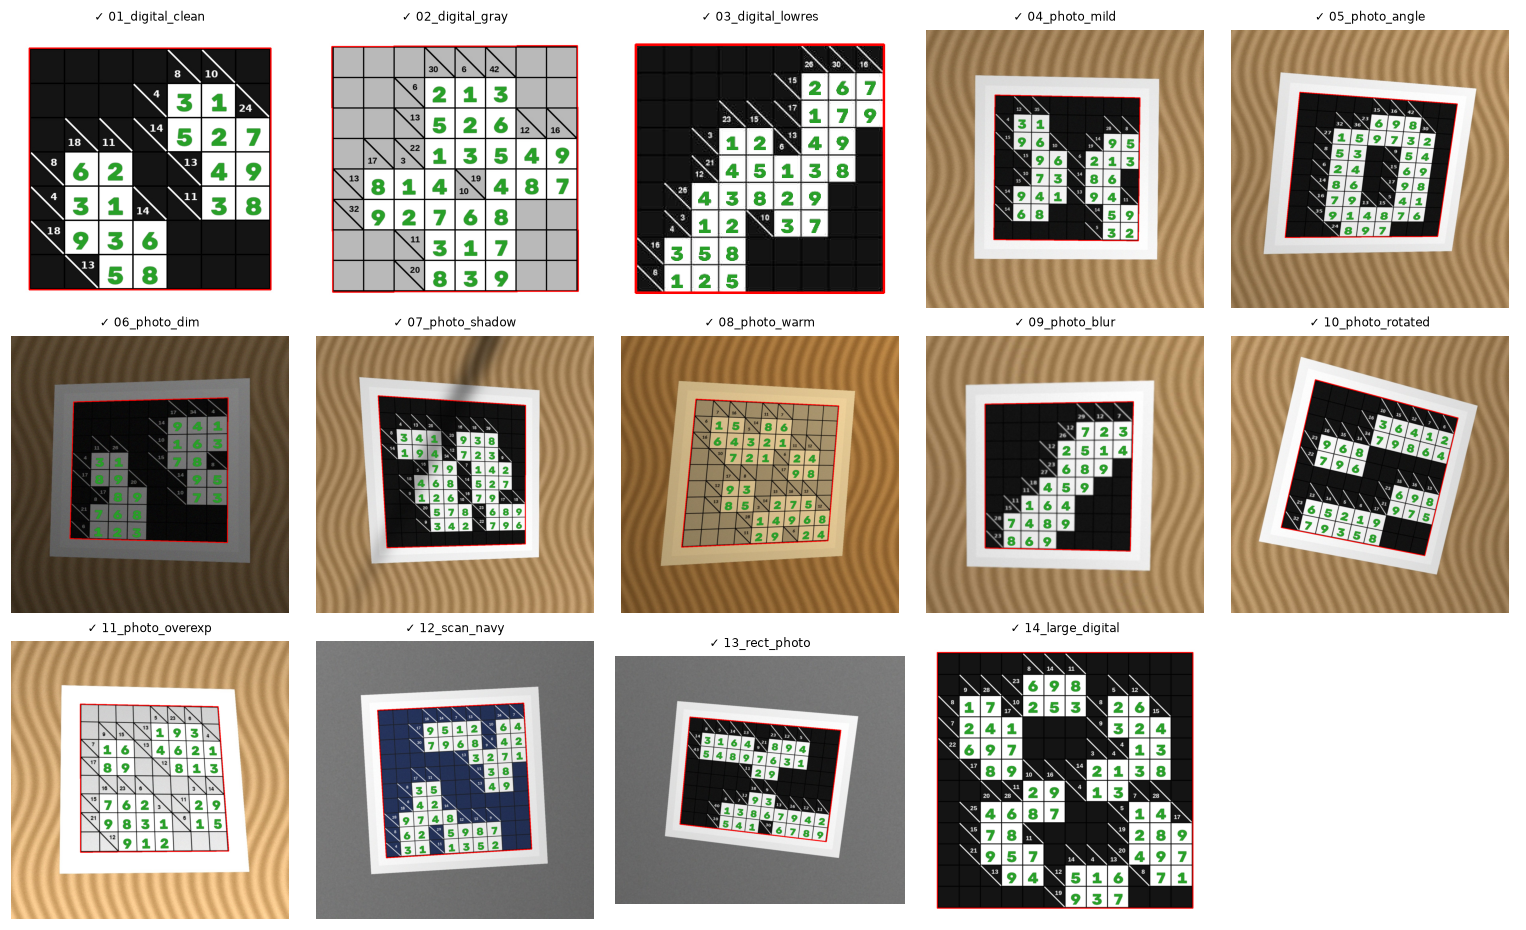

Soluciones correctas extremo a extremo: 14 / 14


,imagen,t_preproc,t_board,t_grid,t_cells,t_ocr,t_total,t_solver,correcta
0,01_digital_clean,0.2,13.1,8.0,4.1,22.8,77.1,0.0,True
1,02_digital_gray,0.2,11.5,5.7,4.8,25.6,61.8,0.1,True
2,03_digital_lowres,0.1,9.7,5.0,6.2,24.7,50.4,0.1,True
3,04_photo_mild,0.8,29.7,6.4,5.9,29.5,145.8,0.1,True
4,05_photo_angle,0.8,35.1,6.2,7.7,31.3,155.3,0.2,True
5,06_photo_dim,0.6,24.6,5.4,6.0,28.2,139.1,0.1,True
6,07_photo_shadow,0.6,35.6,5.4,7.9,36.8,160.4,0.1,True
7,08_photo_warm,1.0,25.2,5.8,7.2,46.3,161.2,0.1,True
8,09_photo_blur,0.6,33.4,5.3,6.4,21.0,155.5,0.1,True
9,10_photo_rotated,0.6,35.8,5.6,7.8,43.0,167.5,0.1,True


In [27]:
outs, trows = [], []
for pth in imgs:
    n = os.path.basename(pth)[:-4]
    pr = solve_image(pth, clf, backend=BACKEND)
    ok = pr.solve.solved and pr.solve.solution == gts[n].solution
    trows.append({"imagen": n, **{f"t_{k}": 1000 * v for k, v in pr.vision.timings.items()},
                  "t_solver": 1000 * (pr.solve.time_s + pr.solve.time_unique_s), "t_total": 1000 * pr.total_s,
                  "correcta": ok})
    outs.append((n, pr.overlay if pr.overlay is not None else cv2.imread(pth), ok))
times = pd.DataFrame(trows); times.to_csv(f"{RES}/pipeline_times.csv", index=False)
fig, axs = plt.subplots(3, 5, figsize=(14, 8.5))
for ax in axs.ravel(): ax.axis("off")
for ax, (n, o, ok) in zip(axs.ravel(), outs):
    ax.imshow(cv2.cvtColor(o, cv2.COLOR_BGR2RGB)); ax.set_title(("✓ " if ok else "✗ ") + n, fontsize=8)
plt.tight_layout(); save(fig, "overlays"); plt.show()
print("Soluciones correctas extremo a extremo:", times.correcta.sum(), "/", len(times))
times.round(1)

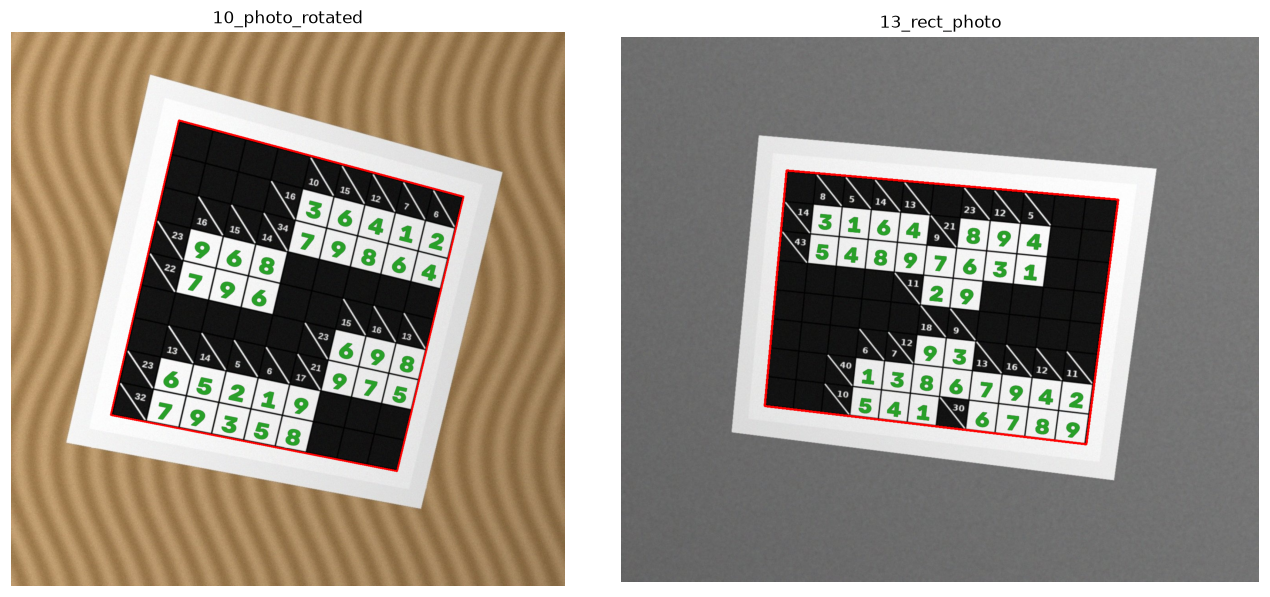

Tiempo medio por etapa (ms):
t_preproc     0.5
t_board      24.4
t_grid        5.8
t_cells       6.8
t_ocr        35.2
t_solver      0.1


In [28]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, n in zip(axs, ["10_photo_rotated", "13_rect_photo"]):
    o = [x for x in outs if x[0] == n][0][1]
    ax.imshow(cv2.cvtColor(o, cv2.COLOR_BGR2RGB)); ax.axis("off"); ax.set_title(n)
plt.tight_layout(); save(fig, "overlay_examples"); plt.show()
t = times[[c for c in times.columns if c.startswith("t_") and c not in ("t_total",)]].mean()
print("Tiempo medio por etapa (ms):"); print(t.round(1).to_string())

## 5. Exportación de tablas para el informe

In [30]:
def tex_table(df, path, fmt="%.3f"):
    with open(path, "w") as f:
        f.write(df.to_latex(index=False, float_format=lambda v: fmt % v, escape=True))
s2 = summ.T.reset_index().rename(columns={"index": "métrica", "MLP + corrección": "MLP+corr.",
                                          "MLP sin corrección": "MLP", "Tesseract 5": "Tesseract"})
tex_table(s2, f"{RES}/tab_vision_summary.tex")
pi = main[["image", "cells_acc", "clues_total", "clues_ok"]].copy()
pi["raw"] = evals["MLP sin corrección"].clues_ok.values
pi["tess"] = evals["Tesseract 5"].clues_ok.values
pi["resuelto"] = main.correct_solution.map({True: "sí", False: "no"}).values
pi = pi.rename(columns={"image": "imagen", "cells_acc": "celdas", "clues_total": "pistas",
                        "clues_ok": "MLP+corr.", "raw": "MLP", "tess": "Tesseract"})
pi["imagen"] = pi["imagen"].str.replace("_", " ")
tex_table(pi, f"{RES}/tab_vision_per_image.tex")
bt = bench.groupby(["size", "cfg"]).agg(ms=("total_ms", "mean"), nod=("nodes", "mean")).unstack("cfg")
bt.columns = [f"{c.replace('_', '-')} {'ms' if a == 'ms' else 'nodos'}" for a, c in bt.columns]
bt.insert(0, "celdas", bench.groupby("size").white.mean())
bt = bt.reset_index().rename(columns={"size": "n"})
tex_table(bt, f"{RES}/tab_bench.tex", "%.2f")
pr2 = prop.copy(); pr2["imagen"] = pr2["imagen"].str.replace("_", " ")
tex_table(pr2, f"{RES}/tab_root_prop.tex", "%.1f")
with open(f"{RES}/macros.tex", "w") as f:
    f.write("\\newcommand{\\solverbackend}{%s}\n" % ("OR-Tools CP-SAT" if HAS_ORTOOLS else "motor CP propio (Python)"))
    f.write("\\newcommand{\\valacc}{%.2f}\n" % (100 * acc_val))
print(open(f"{RES}/macros.tex").read()); print(sorted(os.listdir(RES)))

\newcommand{\solverbackend}{motor CP propio (Python)}
\newcommand{\valacc}{94.36}

['bench.csv', 'macros.tex', 'pipeline_times.csv', 'robustness.csv', 'root_propagation.csv', 'tab_bench.tex', 'tab_root_prop.tex', 'tab_vision_per_image.tex', 'tab_vision_summary.tex', 'vision_per_image.csv', 'vision_summary.csv']


## 6. Conclusiones
* El pipeline lee correctamente la grilla, las celdas y las pistas en todas las condiciones del dataset, y resuelve los 14 puzzles sin intervención manual.
* La red propia supera a Tesseract en este dominio (dígitos pequeños, invertidos y mezclados con la diagonal); la corrección guiada por restricciones (rango + invariante global de sumas) elimina los errores residuales.
* El modelo CP con restricciones globales resuelve y **prueba la unicidad** en milisegundos; la propagación GAC de `AllDifferent ∧ Sum` fija la mayoría de las celdas antes de buscar.
* Límites: desenfoque σ ≥ 2 px degrada el OCR (ver barrido de robustez); tableros sin margen de papel visible usan una estimación de iluminación más débil.